# Vacuum Rabi Oscillation

Lecturer: **Yi-Te Huang**

---

In the [Larmor precession tutorial](2_Larmor_precession.ipynb), a single spin precessed under a *classical* magnetic field. Here, we couple a two-level atom to a single-mode cavity (a *quantized* electromagnetic field), which is known as the Jaynes–Cummings model. In this tutorial, we can observe a single excitation swap coherently back and forth between the atom and cavity. This is the vacuum Rabi oscillation, one of the founding phenomena of cavity quantum electrodynamics.

## Table of Content

- Jaynes–Cummings model
- Isolated evolution: `sesolve`
  - Resonance regime
  - Detuned regime
- Damped vacuum Rabi oscillations: `mesolve`
- A finite-temperature environment
- Final remarks

In [1]:
# import packages
using QuantumToolbox
using CairoMakie

## Jaynes–Cummings model

A two-level atom (with transition frequency $\omega_\mathrm{a}$) is described by the Pauli-$Z$ operator ($\hat{\sigma}_z$), and the single-mode cavity (with frequency $\omega_\mathrm{c}$) is described by the bosonic ladder operators ($\hat{a}$ and $\hat{a}^\dagger$) truncated at a finite Fock-space cutoff $N$. Under the rotating-wave approximation (RWA), only excitation-conserving terms survive, giving the Jaynes–Cummings Hamiltonian ($\hbar=1$)

```math
\hat{H} = \frac{\omega_\mathrm{a}}{2}\hat{\sigma}_z + \omega_\mathrm{c}\,\hat{a}^\dagger\hat{a} + g\left(\hat{a}^\dagger\hat{\sigma}_- + \hat{\sigma}_+\hat{a}\right),
```

where $g$ is the atom-cavity coupling strength.

## Isolated evolution: `sesolve`

### Resonance regime

We first consider when the cavity frequency resonante with the atom, i.e., $\omega_\mathrm{c} = \omega_\mathrm{a}$.

In [2]:
# system parameters
N  = 5     # cavity Fock-space cutoff
ωa = 1.0   # atomic transition frequency
ωc = ωa    # cavity frequency
g  = 0.05  # atom-cavity coupling strength

# atomic operators
σz = sigmaz() ⊗ qeye(N)
σm = sigmam() ⊗ qeye(N)

# cavity operator
a  = qeye(2) ⊗ destroy(N)

# Hamiltonian
H = (ωa / 2) * σz + ωc * a' * a + g * (a' * σm + σm' * a)


Quantum Object:   type=Operator()   dims=([2, 5], [2, 5])   size=(10, 10)   ishermitian=true
10×10 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 18 stored entries:
  0.5+0.0im            ⋅                ⋅      …            ⋅          ⋅    
      ⋅            1.5+0.0im            ⋅                   ⋅          ⋅    
      ⋅                ⋅            2.5+0.0im     0.0866025+0.0im      ⋅    
      ⋅                ⋅                ⋅                   ⋅      0.1+0.0im
      ⋅                ⋅                ⋅                   ⋅          ⋅    
      ⋅                ⋅                ⋅      …            ⋅          ⋅    
 0.05+0.0im            ⋅                ⋅                   ⋅          ⋅    
      ⋅      0.0707107+0.0im            ⋅                   ⋅          ⋅    
      ⋅                ⋅      0.0866025+0.0im           2.5+0.0im      ⋅    
      ⋅                ⋅                ⋅                   ⋅      3.5+0.0im

`sesolve` propagates the joint atom-cavity state vector $|\psi(t)\rangle$ by integrating the Schrödinger equation

```math
i\frac{d}{dt}|\psi(t)\rangle = \hat{H}|\psi(t)\rangle.
```

We start with the atom excited and the cavity empty, $|\psi_0\rangle = |e\rangle\otimes|0\rangle$. Because $\hat{H}$ conserves the total excitation number, the state never leaves the two-dimensional subspace spanned by $|e,0\rangle$ and $|g,1\rangle$: the single excitation simply oscillates between atom and cavity at the vacuum Rabi frequency $\Omega_\mathrm{Rabi} = 2g$, corresponding to an oscillation period of 

```math
T_\mathrm{Rabi}=\frac{2\pi}{\Omega_\mathrm{Rabi}} = \frac{\pi}{g}.
```

We track this oscillation with two observables: the intracavity photon number $\hat{a}^\dagger\hat{a}$, and the atomic excited-state population $\hat{P}_e = |e\rangle\langle e|$.


In [3]:
# following qutip's convention:
# sigmam() * ψe = ψg
# sigmap() * ψg = ψe
ψe = basis(2, 0) # atomic excited state
ψg = basis(2, 1) # atomic ground  state

# initial state
ψ0 = ψe ⊗ fock(N, 0)

# observables (for calculate expectation values)
N_op  = a' * a
Pe_op = (ψe * ψe') ⊗ qeye(N)
e_ops = [N_op, Pe_op, N_op + Pe_op]

# solver
T_Rabi = 2π / 2g # Rabi frequency: 2g
tlist = range(0, 6 * T_Rabi, 400)
sol_se = sesolve(H, ψ0, tlist; e_ops = e_ops)

[sesolve] 100%|███████████████████████████| Time: 0:00:08 (20.75 ms/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqVerner.Vern7{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Bool}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), false)
abstol = 1.0e-8
reltol = 1.0e-6


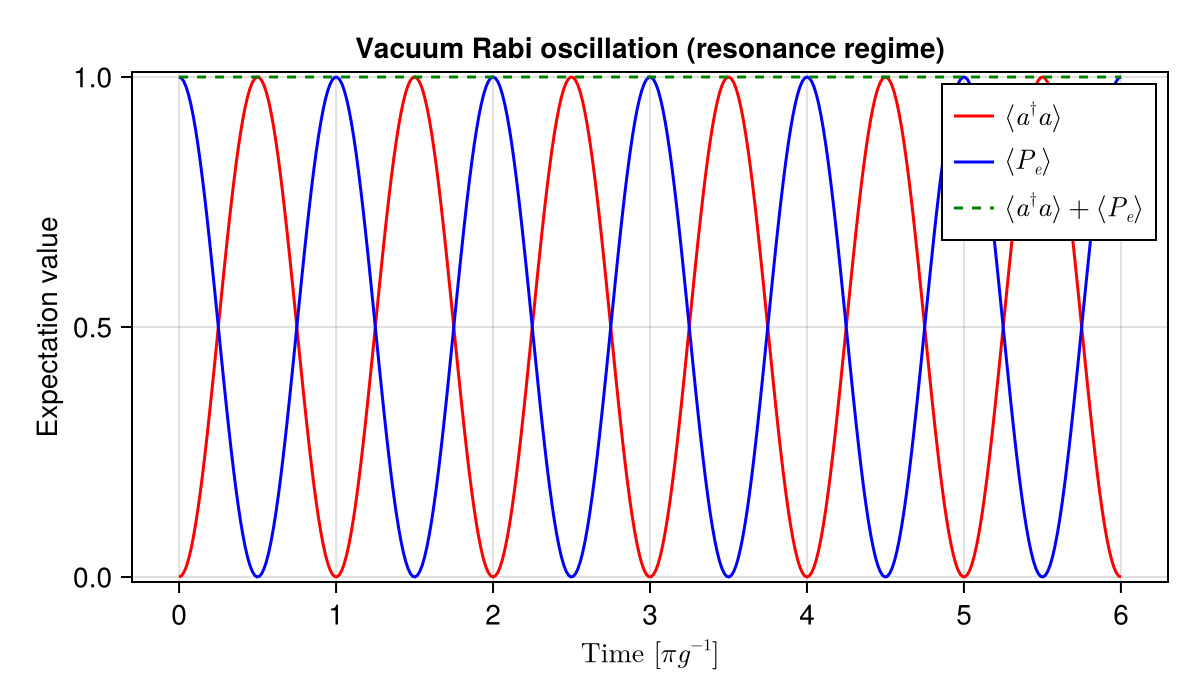

In [4]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = L"Time $[πg^{-1}]$",
    ylabel = "Expectation value",
    title = "Vacuum Rabi oscillation (resonance regime)",
    limits = (nothing, nothing, -0.01, 1.01),
)

lines!(ax, tlist / T_Rabi, real(sol_se.expect[1, :]), color = :red, label = L"\langle a^\dagger a\rangle")
lines!(ax, tlist / T_Rabi, real(sol_se.expect[2, :]), color = :blue, label = L"\langle P_e \rangle")
lines!(ax, tlist / T_Rabi, real(sol_se.expect[3, :]), color = :green, label = L"\langle a^\dagger a\rangle + \langle P_e \rangle", linestyle = :dash)
axislegend(ax, position = :rt)

fig

The photon number and the excited-state population oscillate between each other, always summing to $1$: whenever the atom loses (gains) excitation, the cavity gains (loses) exactly one photon. Because `sesolve` is unitary, this exchange repeats forever.

### Detuned regime

When the cavity frequency $\omega_\mathrm{c}$ differs from the atomic transition frequency $\omega_\mathrm{a}$, we enter the *detuned* regime, i.e.,
```math
\omega_\mathrm{c} = \omega_\mathrm{a} + \Delta.
```

In [5]:
# Detuned case
Δ = 0.08 * ωa  # detuning
ωc_detuned = ωa + Δ

# Hamiltonian with detuning
H_detuned = (ωa / 2) * σz + ωc_detuned * a' * a + g * (a' * σm + σm' * a)

# solver
sol_detuned = sesolve(H_detuned, ψ0, tlist; e_ops = e_ops)

[sesolve] 100%|███████████████████████████| Time: 0:00:00 (13.97 μs/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqVerner.Vern7{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Bool}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), false)
abstol = 1.0e-8
reltol = 1.0e-6


In this case, the energy mismatch between the atom and the cavity modifies the oscillation behavior. The vacuum Rabi oscillations now occur at a *generalized Rabi frequency*

```math
\Omega_\mathrm{Rabi}'= \sqrt{4g^2 + \Delta^2},
```

which depends on both the coupling strength $g$ and the detuning $\Delta$. Furthermore, some excitation remains in the atom, and the maximum cavity photon number is given by:

```math
\langle \hat{a}^\dagger \hat{a}\rangle_{\max} = \frac{4g^2}{4g^2 + \Delta^2}.
```

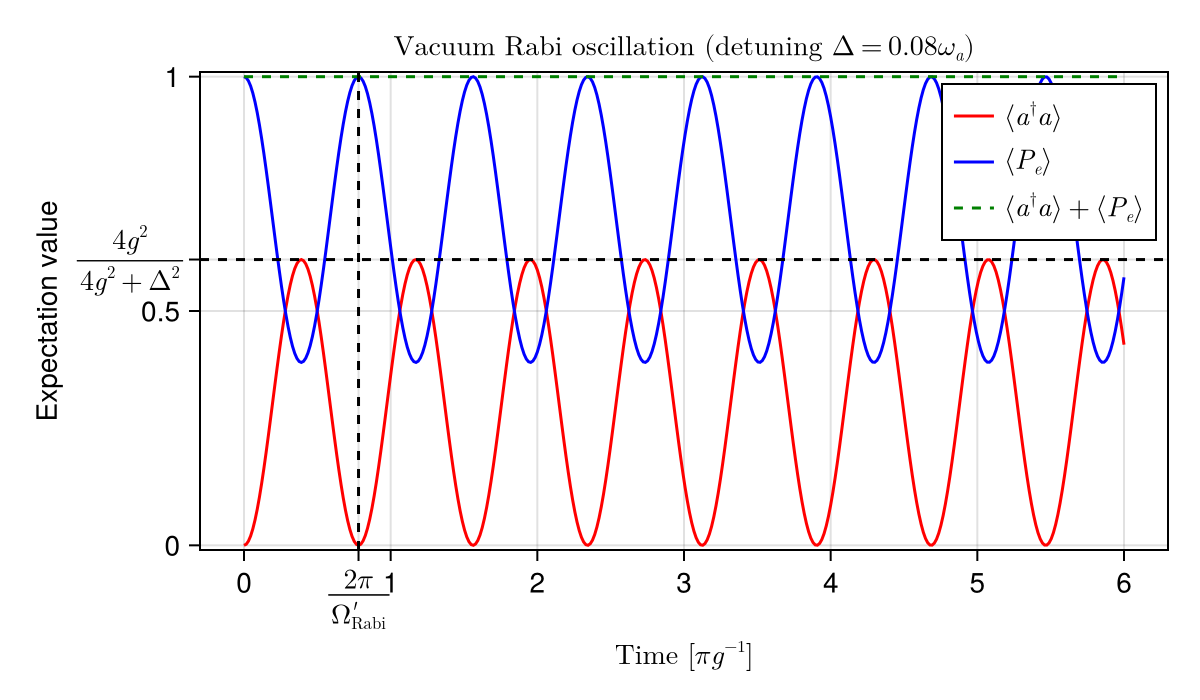

In [6]:
Ω_detuned = √(4g^2 + Δ^2)  # generalized Rabi frequency

fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = L"Time $[πg^{-1}]$",
    ylabel = "Expectation value",
    title = L"Vacuum Rabi oscillation (detuning $\Delta=%$(Δ)\omega_a$)",
    xticks = ([0, 1, 2, 3, 4, 5, 6, 2π / Ω_detuned / T_Rabi], ["0", "1", "2", "3", "4", "5", "6", L"\frac{2\pi}{\Omega_\mathrm{Rabi}'}"]),
    yticks = ([0, 0.5, 1, 4g^2 / (4g^2 + Δ^2)], ["0", "0.5", "1", L"\frac{4g^2}{4g^2 + \Delta^2}"]),
    limits = (nothing, nothing, -0.01, 1.01),
)

lines!(ax, tlist / T_Rabi, real(sol_detuned.expect[1, :]), color = :red, label = L"\langle a^\dagger a\rangle")
lines!(ax, tlist / T_Rabi, real(sol_detuned.expect[2, :]), color = :blue, label = L"\langle P_e \rangle")
lines!(ax, tlist / T_Rabi, real(sol_detuned.expect[3, :]), color = :green, label = L"\langle a^\dagger a\rangle + \langle P_e \rangle", linestyle = :dash)

hlines!(ax, [4g^2 / (4g^2 + Δ^2)], color = :black, linestyle = :dash)
vlines!(ax, [2π / Ω_detuned / T_Rabi], color = :black, linestyle = :dash)

axislegend(ax, position = :rt)

fig

As detuning increases:
- Oscillations become faster ($\Omega_\mathrm{Rabi}'$ increases)
- The amplitude $\frac{4g^2}{4g^2+\Delta^2}$ decreases (less efficient energy transfer)
- At large detuning ($\Delta \gg g$), the atom-cavity system becomes effectively decoupled: the atom stays mostly excited and the cavity remains mostly empty

This behavior has important practical implications in cavity QED experiments: maintaining resonance ($\Delta \approx 0$) is crucial for efficient quantum state transfer, while controlled detuning can be used to suppress unwanted interactions.

## Damped vacuum Rabi oscillations: `mesolve`

Real cavities leak photons through imperfect mirrors, and real atoms spontaneously emit into the environment. Once these loss channels are included the joint state is in general mixed, so we consider its density matrix $\hat{\rho}(t)$ instead, evolved with `mesolve` under the Lindblad master equation

```math
\frac{d\hat{\rho}}{dt} = -i\left[\hat{H},\hat{\rho}\right] + \sum_k \left(\hat{C}_k\hat{\rho}\hat{C}_k^\dagger - \frac{1}{2}\left\{\hat{C}_k^\dagger\hat{C}_k,\hat{\rho}\right\}\right).
```

We add both loss channels as collapse operators $\hat{C}_k$: 

- $\hat{C}_1=\sqrt{\gamma}\hat{\sigma}_-$ (atomic decay at rate $\gamma$)
- $\hat{C}_2=\sqrt{\kappa}\hat{a}$ (cavity photon loss at rate $\kappa$)

In [7]:
γ = 0.01  # atomic energy decay rate
κ = 0.02  # cavity photon loss  rate

# collapse operators
c_ops = [
    √(γ) * σm,
    √(κ) * a
]

sol_me = mesolve(H, ψ0, tlist, c_ops; e_ops = e_ops)

[mesolve] 100%|███████████████████████████| Time: 0:00:01 ( 4.93 ms/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqLowOrderRK.DP5{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial())
abstol = 1.0e-8
reltol = 1.0e-6


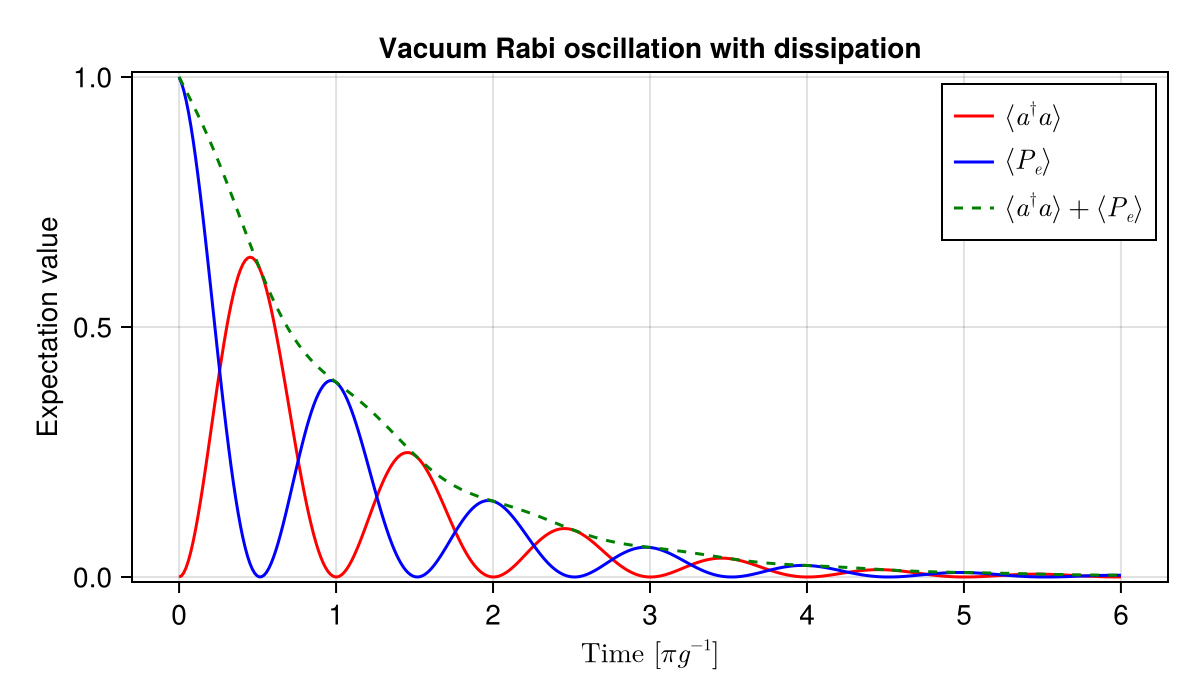

In [8]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = L"Time $[πg^{-1}]$",
    ylabel = "Expectation value",
    title = "Vacuum Rabi oscillation with dissipation",
    limits = (nothing, nothing, -0.01, 1.01),
)

lines!(ax, tlist / T_Rabi, real(sol_me.expect[1, :]), color = :red, label = L"\langle a^\dagger a\rangle")
lines!(ax, tlist / T_Rabi, real(sol_me.expect[2, :]), color = :blue, label = L"\langle P_e \rangle")
lines!(ax, tlist / T_Rabi, real(sol_me.expect[3, :]), color = :green, label = L"\langle a^\dagger a\rangle + \langle P_e \rangle", linestyle = :dash)
axislegend(ax, position = :rt)

fig

In this case, both the photon number and the excited-state population now decay as they oscillate: energy irreversibly leaks out of the atom-cavity system until it reaches the joint ground state $|g, 0\rangle$.


## A finite-temperature environment

The previous section assumed a zero-temperature environment, so only the decay (loss) processes were present. At finite temperature, thermal fluctuations can also incoherently pump excitations into the system.

At each transition frequency, the mean thermal occupation number is given by the Bose-Einstein distribution

```math
\bar{n}(\omega, k_\mathrm{B}T)=\frac{1}{e^{\hbar\omega/k_\mathrm{B}T}-1}.
```

This value can be computed by the function `n_thermal(ω, kT)` given in `QuantumToolbox` with `kT` is equivalent to $k_\mathrm{B}T/\hbar$ in the same frequency unit as $\omega_\mathrm{a}$ and $\omega_\mathrm{c}$.

The effects of thermal fluctuations on the system can be described by four Lindblad collapse operators [where $\bar{n}_\mathrm{a}=\bar{n}(\omega_\mathrm{a},k_\mathrm{B}T)$ and $\bar{n}_\mathrm{c}=\bar{n}(\omega_\mathrm{c},k_\mathrm{B}T)$]:

- $\hat{C}_1 = \sqrt{\gamma\,(1+\bar{n}_\mathrm{a})}\,\hat{\sigma}_-$: atomic decay into the environment.
- $\hat{C}_2 = \sqrt{\gamma\,\bar{n}_\mathrm{a}}\,\hat{\sigma}_+$: atomic pumping from the environment.
- $\hat{C}_3 = \sqrt{\kappa\,(1+\bar{n}_\mathrm{c})}\,\hat{a}$: cavity photon decay into the environment.
- $\hat{C}_4 = \sqrt{\kappa\,\bar{n}_\mathrm{c}}\,\hat{a}^\dagger$: cavity photon pumping from the environment.

Note that in the zero-temperature limit ($\bar{n}_\mathrm{a}\to 0$ and $\bar{n}_\mathrm{c} \to 0$), the pumping channels $\hat{C}_2$ and $\hat{C}_4$ vanish, recovering the pure-decay dynamics discussed in the previous section.

At the long-time limit, the system thermalizes with the environment, but the atom and cavity observables approach different thermal values:

- for a two-level atom: $\langle \hat{P}_e\rangle_\mathrm{th}=\frac{\bar{n}_\mathrm{a}}{1+2\bar{n}_\mathrm{a}}$
- for the single-mode cavity: $\langle \hat{a}^\dagger \hat{a}\rangle_\mathrm{th}=\bar{n}_\mathrm{c}$

In [9]:
# thermal effects
kT = 0.5 * ωa
nc = n_thermal(ωc, kT)
na = n_thermal(ωa, kT)

# collapse operators
c_ops = [
    √(γ * (1 + na)) * σm,
    √(γ * (    na)) * σm',
    √(κ * (1 + nc)) * a,
    √(κ * (    nc)) * a',
]

# solver
sol_th = mesolve(H, ψ0, tlist, c_ops; e_ops = e_ops)

[mesolve] 100%|███████████████████████████| Time: 0:00:00 (13.86 μs/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 3
ODE alg.: OrdinaryDiffEqLowOrderRK.DP5{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial())
abstol = 1.0e-8
reltol = 1.0e-6


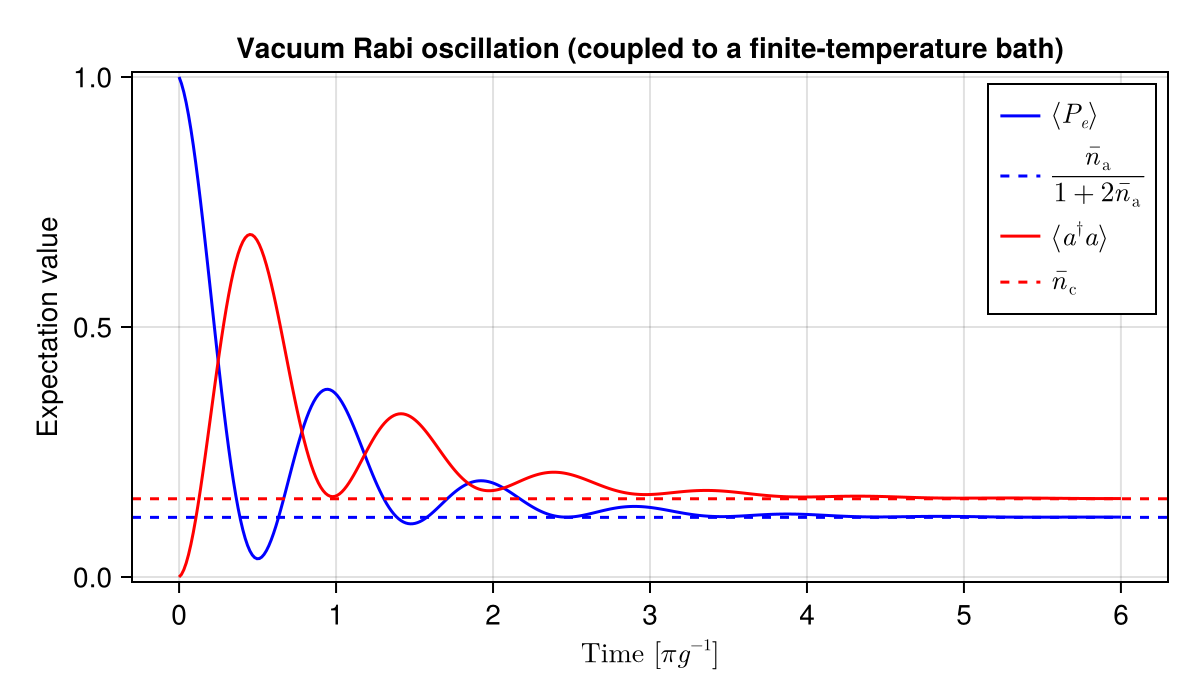

In [10]:
fig = Figure(size = (600, 350))
ax = Axis(
    fig[1, 1],
    xlabel = L"Time $[πg^{-1}]$",
    ylabel = "Expectation value",
    title = "Vacuum Rabi oscillation (coupled to a finite-temperature bath)",
    limits = (nothing, nothing, -0.01, 1.01),
)

lines!(ax, tlist / T_Rabi, real(sol_th.expect[2, :]), color = :blue, label = L"\langle P_e\rangle")
hlines!(ax, [na / (1 + 2na)], color = :blue, linestyle = :dash, label = L"\frac{\bar{n}_\mathrm{a}}{1+2\bar{n}_\mathrm{a}}")

lines!(ax, tlist / T_Rabi, real(sol_th.expect[1, :]), color = :red, label = L"\langle a^\dagger a\rangle")
hlines!(ax, [nc], color = :red, linestyle = :dash, label = L"\bar{n}_\mathrm{c}")

axislegend(ax, position = :rt)

fig

The dashed lines indicates the thermal equilibrium values for the cavity photon number (red) and atomic excited-state population (blue). The system reaches its stationary state as thermal pumping balances decay.

## Final remarks

One more thing worth checking whenever you truncate an infinite-dimensional Hilbert space: is the cutoff $N$ large enough? A quick way to check is to rerun the simulation with a larger $N$ (e.g. `N = 10`) and confirm the curves above don't change. If they do, the truncation was too aggressive for the given coupling, decay rates, and environment temperature.
